# 👑 Analisis Graf: Silsilah Kerajaan Nusantara
**Mata Kuliah Graf - Departemen Sistem Informasi ITS**

Notebook ini digunakan untuk membangun graf silsilah kekerabatan dan menjalankan 3 algoritma utama:
1. **Degree Centrality** (Mencari tokoh paling sentral/berpengaruh)
2. **Community Detection** (Mencari klaster wangsa/dinasti alami)
3. **Jaccard Similarity** (Mencari kemiripan antar tokoh)

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import community

print("✅ Library berhasil di-load!")

# [NANTI GANTI BAGIAN INI PAKAI: df = pd.read_csv('../data/dataset_gabungan_uts_graf.csv')]
# --- START DUMMY DATA ---
data_dummy = {
    'Nama_Tokoh': ['Raden Wijaya', 'Gayatri', 'Kertanegara', 'Hayam Wuruk', 'Tribhuwana'],
    'Ayah': ['Lembu Tal', 'Kertanegara', '', 'Kertawardhana', 'Raden Wijaya'],
    'Ibu': ['', '', '', 'Tribhuwana', 'Gayatri'],
    'Pasangan': ['Gayatri', '', '', '', 'Kertawardhana']
}
df = pd.DataFrame(data_dummy)
# --- END DUMMY DATA ---

display(df.head())

✅ Library berhasil di-load!


,Nama_Tokoh,Ayah,Ibu,Pasangan
0,Raden Wijaya,Lembu Tal,,Gayatri
1,Gayatri,Kertanegara,,
2,Kertanegara,,,
3,Hayam Wuruk,Kertawardhana,Tribhuwana,
4,Tribhuwana,Raden Wijaya,Gayatri,Kertawardhana


In [2]:
# Inisialisasi Graf Kosong
G = nx.Graph()

# Looping tiap baris data untuk membuat relasi
for index, row in df.iterrows():
    tokoh = str(row['Nama_Tokoh'])
    ayah = str(row['Ayah'])
    ibu = str(row['Ibu'])
    pasangan = str(row['Pasangan'])
    
    # Tambahkan Node Utama
    G.add_node(tokoh)
    
    # Tambahkan Edge (Relasi) jika datanya tidak kosong
    if ayah and ayah != 'nan':
        G.add_edge(ayah, tokoh, relasi="AYAH_DARI")
    if ibu and ibu != 'nan':
        G.add_edge(ibu, tokoh, relasi="IBU_DARI")
    if pasangan and pasangan != 'nan':
        G.add_edge(tokoh, pasangan, relasi="MENIKAH_DENGAN")

print(f"🕸️ Graf terbentuk: {G.number_of_nodes()} Nodes dan {G.number_of_edges()} Edges.")

🕸️ Graf terbentuk: 7 Nodes dan 8 Edges.


In [3]:
print("🔥 HASIL ANALISIS ALGORITMA GRAF 🔥\n")

# 1. CENTRALITY (Degree Centrality)
print("1️⃣ TOKOH PALING SENTRAL (Degree Centrality):")
centrality = nx.degree_centrality(G)
sorted_centrality = sorted(centrality.items(), key=lambda item: item[1], reverse=True)
for t, skor in sorted_centrality[:3]:
    print(f"   👑 {t}: {skor:.2f}")

# 2. COMMUNITY DETECTION (Greedy Modularity)
print("\n2️⃣ DETEKSI KLASTER DINASTI (Community Detection):")
komunitas = list(community.greedy_modularity_communities(G))
for i, sirkel in enumerate(komunitas):
    print(f"   🏰 Klaster {i+1}: {list(sirkel)}")

# 3. SIMILARITY (Jaccard Coefficient)
print("\n3️⃣ KEMIRIPAN TOKOH (Jaccard Similarity):")
preds = nx.jaccard_coefficient(G)
sorted_preds = sorted(preds, key=lambda x: x[2], reverse=True)
for u, v, p in sorted_preds[:3]:
    if p > 0:
        print(f"   🪞 {u} & {v} (Skor Kemiripan: {p:.2f})")

🔥 HASIL ANALISIS ALGORITMA GRAF 🔥

1️⃣ TOKOH PALING SENTRAL (Degree Centrality):
   👑 Tribhuwana: 0.67
   👑 Raden Wijaya: 0.50
   👑 Gayatri: 0.50

2️⃣ DETEKSI KLASTER DINASTI (Community Detection):
   🏰 Klaster 1: ['Kertanegara', 'Lembu Tal', 'Gayatri', 'Raden Wijaya']
   🏰 Klaster 2: ['Tribhuwana', 'Hayam Wuruk', 'Kertawardhana']

3️⃣ KEMIRIPAN TOKOH (Jaccard Similarity):
   🪞 Raden Wijaya & Kertanegara (Skor Kemiripan: 0.33)
   🪞 Lembu Tal & Gayatri (Skor Kemiripan: 0.33)
   🪞 Raden Wijaya & Hayam Wuruk (Skor Kemiripan: 0.25)


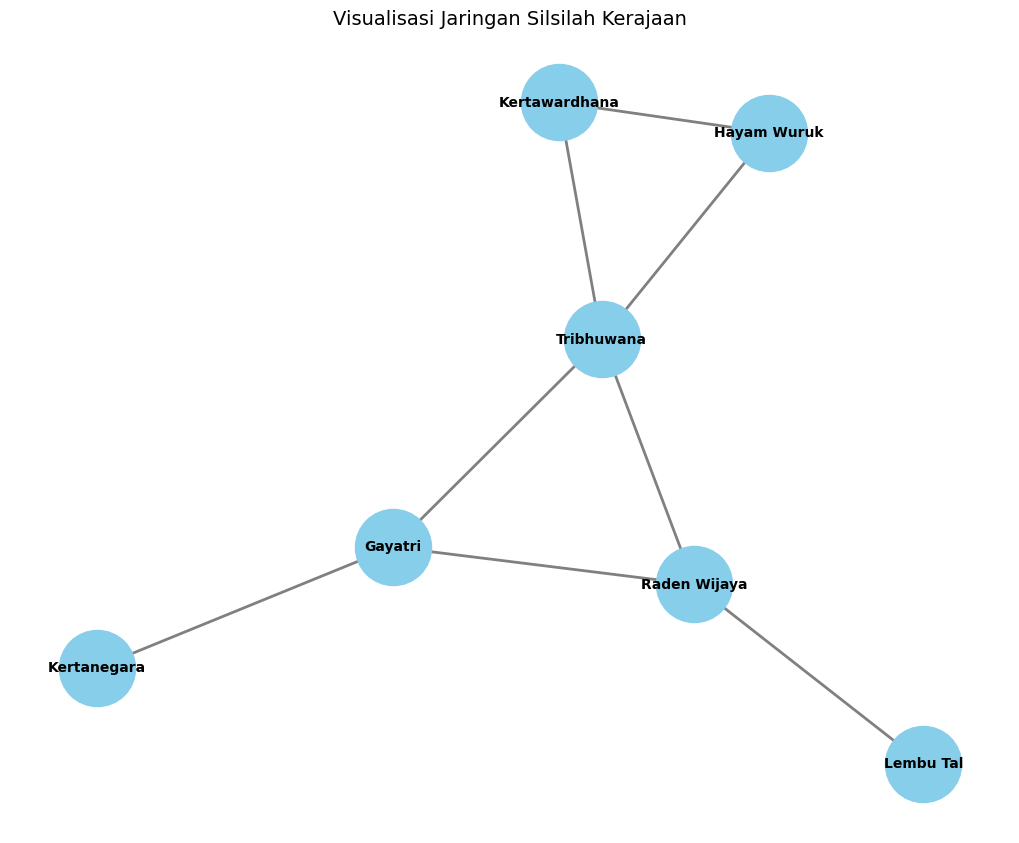

In [4]:
plt.figure(figsize=(10, 8))

# Atur posisi layout biar estetik
pos = nx.spring_layout(G, seed=42)

# Gambar Node dan Label
nx.draw(G, pos, with_labels=True, node_color='skyblue', 
        node_size=3000, font_size=10, font_weight='bold', 
        edge_color='gray', width=2)

plt.title("Visualisasi Jaringan Silsilah Kerajaan", fontsize=14)
plt.show()